# N-BEATS — One Series

Deep learning with no feature engineering, and still interpretable.

| | |
|---|---|
| **Course section** | N-BEATS |
| **Data** | `electricity.csv`, `best_params.csv` |
| **Libraries** | `darts` (`NBEATSModel`), `torch` |
| **Runs on** | GPU strongly recommended |

> **Turn the GPU on before you run this.** In Colab: `Runtime → Change runtime type → T4 GPU`.
> On CPU these cells finish eventually, but not in a sitting.

---

Part of **[Master Time Series Analysis and Forecasting with Python](https://www.udemy.com/course/forecasting-python/?referralCode=63045C9CC807EB1EBD9A)** · [All notebooks](https://github.com/diogoalvesderesende/time-series-forecasting-python)

Roadmap
------
1. Mount Drive, install/import libs, and set path
2. Load hourly DE electricity series and basic EDA
3. Build Darts `TimeSeries` + encoders + scaling
4. Random search over N‑BEATS hyperparameters
5. Rolling backtest via `historical_forecasts`
6. Save best params → refit on full history → forecast 24 hours
7. Plot forecast vs actuals

N‑BEATS in 90 seconds
---------------------
* **Architecture**: a stack of fully‑connected *blocks* that output two heads: **backcast** (explains the input) and **forecast** (predicts future). The backcast lets the model iteratively remove explained structure, improving residual modeling.
* **Stacks/Blocks**: You can use many blocks per stack and multiple stacks. Classic paper variants used trend/seasonality stacks; Darts exposes a general N‑BEATS with configurable depth/width.
* **Strengths**: Pure neural approach, fast to train on GPUs, strong on many benchmarks without feature engineering.
* **When to use**: Univariate/multivariate forecasting with enough data, especially when patterns are complex or non‑linear.

Key Darts parameters you tune below
----------------------------------
* `input_chunk_length` (lookback): how many past time steps the model sees. Too short → misses patterns; too long → harder optimization.
* `output_chunk_length` (horizon): how many future steps the model predicts each call (24 here for 24h ahead).
* `num_stacks` → how many stacks of blocks. More stacks = more capacity/expressivity.
* `num_blocks` → blocks per stack. Controls depth per stack.
* `num_layers` → fully‑connected layers per block.
* `layer_widths` → hidden units per FC layer (model width). Larger = more capacity, risk of overfit.
* `n_epochs` → training epochs per fit.
* `add_encoders` → auto‑generates time encodings (cyclic hour/day/week/month), positions, custom attributes; all passed as covariates.
* `pl_trainer_kwargs` → Lightning trainer settings (accelerator/devices). Here set to GPU `[0]`.
* `random_state` → reproducibility for weight init and sampling.

Encoders tip: Using both `cyclic` and `datetime_attribute` for hour/day/week/month gives the model periodic signals. `position` encodes relative positions; `custom` shows how to include arbitrary functions.
"""

# Libraries and Data

In [1]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Path to the folder
%cd /content/drive/MyDrive/Freelance/DataHeroes/Course/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting/N-BEATS

/content/drive/MyDrive/Freelance/DataHeroes/Course/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting/N-BEATS


In [3]:
# Install the darts library
!pip install -q "darts[torch]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.8/808.8 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 56.5 MB/s eta 0:00:00


In [5]:
# Standard Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterSampler

# Darts functions
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import NBEATSModel

In [6]:
# Loading the hourly electricity consumption data
# Set the datetime column ('ds') as index
df = pd.read_csv("electricity.csv", index_col = "ds", parse_dates = True)
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


In [7]:
# Count the number of occurrences of each unique ID in the dataframe
df.unique_id.value_counts()

,count
unique_id,
BE,1680
DE,1680
FR,1680
NP,1680
PJM,1680


In [8]:
# Filter the dataframe to include only rows where the 'unique_id' is "DE"
df = df[df['unique_id'] == "DE"]
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2017-10-22 00:00:00,DE,19.10,587.25,16972.75
2017-10-22 01:00:00,DE,19.03,623.00,16254.50
2017-10-22 02:00:00,DE,16.90,650.00,15940.25
2017-10-22 03:00:00,DE,12.98,687.25,15959.50
2017-10-22 04:00:00,DE,9.24,717.25,16071.50


In [9]:
# Display information about the DataFrame, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1680 entries, 2017-10-22 00:00:00 to 2017-12-30 23:00:00
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   1680 non-null   object 
 1   y           1680 non-null   float64
 2   Exogenous1  1680 non-null   float64
 3   Exogenous2  1680 non-null   float64
dtypes: float64(3), object(1)
memory usage: 65.6+ KB


In [10]:
# Set the frequency of the time series data to hourly
df = df.asfreq("h")

# Exploratory Data Analysis

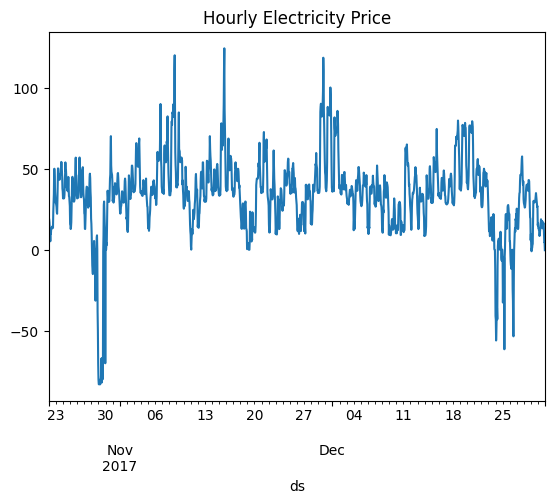

In [11]:
# Plot the hourly electricity price
df['y'].plot(title = 'Hourly Electricity Price')
plt.show()

`seasonal_decompose` - To decompose a time series into its constituent parts to better understand the underlying patterns.

components

- Trend: The overall direction of the series (increasing, decreasing, or stable).
- Seasonal: Repeating patterns at fixed intervals (e.g., daily, weekly, monthly).
- Residual: The remaining variation after removing trend and seasonal components.

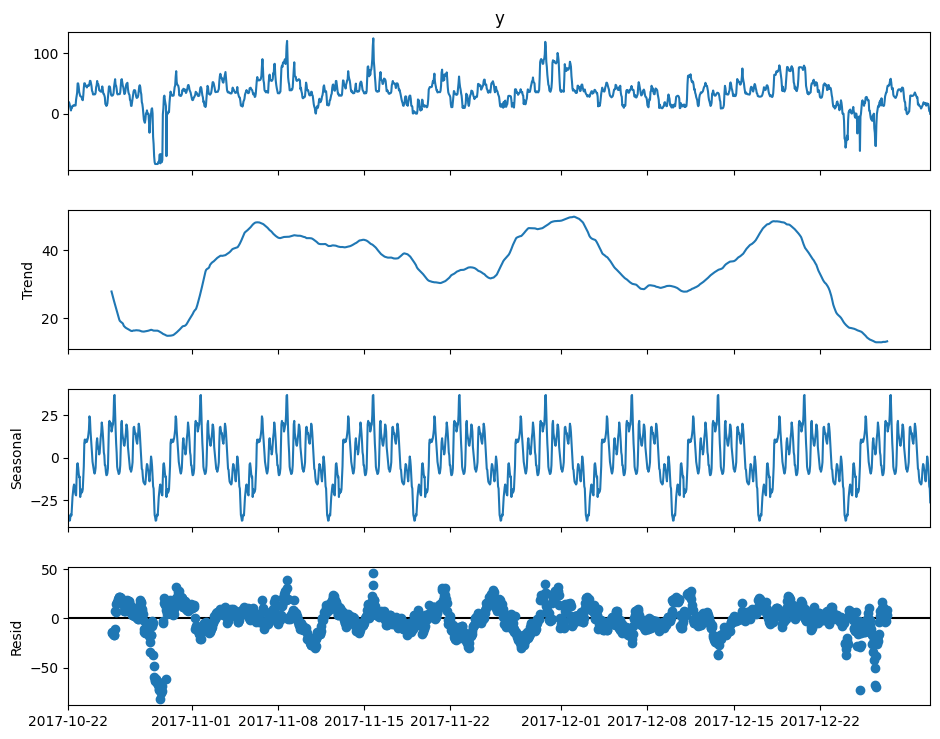

In [12]:
# Perform seasonal decomposition of the bike sharing demand using an additive model
decomposition = seasonal_decompose(df['y'],
                                   model = 'add',
                                   period = 168)

# Plot the decomposed components (trend, seasonal, and residual)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

Autocorrelation measures the correlation between a time series and a lagged version of itself.

Purpose: To identify patterns or repeating cycles in a time series dataset.

Interpretation:
- Values range from -1 to 1.
- 1 indicates perfect positive correlation.
- -1 indicates perfect negative correlation.
- 0 indicates no correlation.

ACF Plot:
- X-axis: Lag periods
- Y-axis: Correlation coefficient

Key Features:
- At lag 0, autocorrelation is always 1 (a series is perfectly correlated with itself).
- Significant spikes at certain lags indicate repeating patterns.


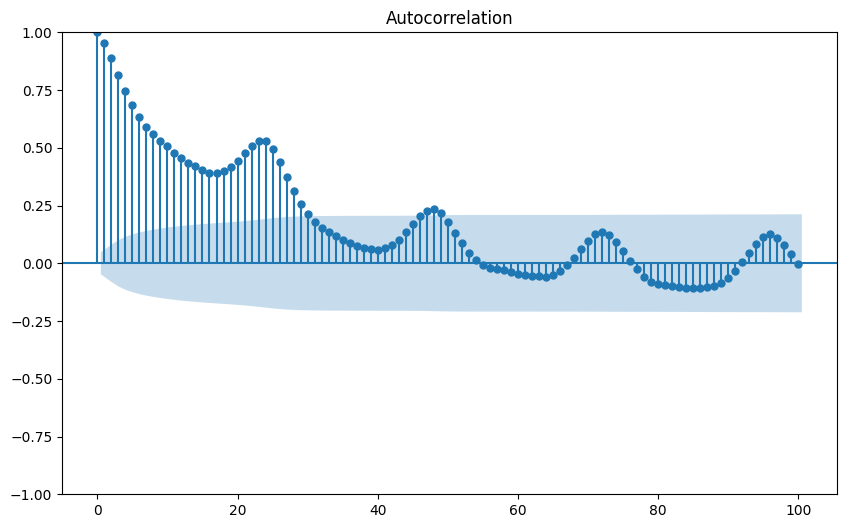

In [13]:
# Plot the autocorrelation function (ACF) for the time series data
fig, ax = plt.subplots(figsize = (10,6))
plot_acf(df['y'], lags = 100, ax = ax) # Generate the ACF plot with 100 lags
plt.show()

PACF measures the correlation between a time series and its lag, after removing the effects of all shorter lags.

Purpose: To identify the direct relationship between an observation and its lag, without intermediate effects.

Main Difference between ACF and PACF:
- ACF: Measures overall correlation at each lag, including indirect effects.
- PACF: Measures direct correlation at each lag, excluding indirect effects.

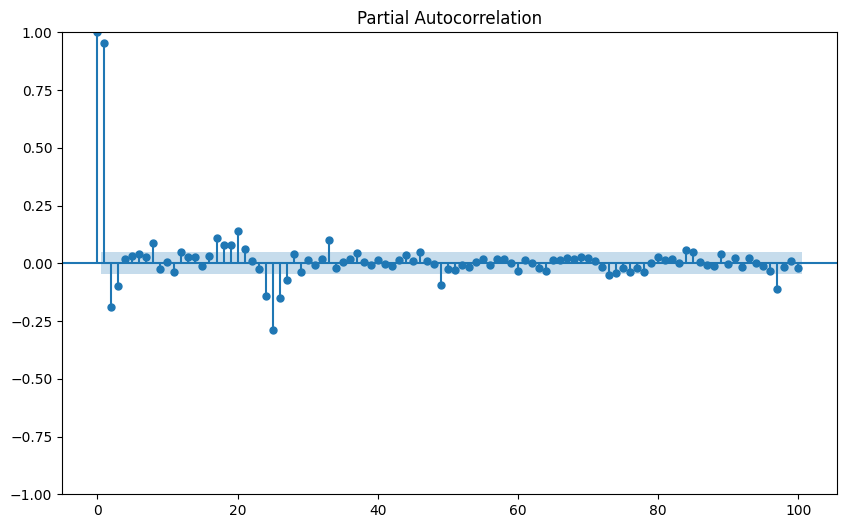

In [14]:
# Plot the partial autocorrelation function (PACF) for the time series data
fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(df['y'], lags = 100, ax = ax) # Generate the PACF plot with 100 lags
plt.show()

# Series And Seasonality

In [15]:
# Prepare a TimeSeries object from the dataframe with Hourly frequency
series = TimeSeries.from_dataframe(df,
                                   value_cols = 'y',
                                   freq = 'h')
series

,y
ds,
2017-10-22 00:00:00,19.10
2017-10-22 01:00:00,19.03
2017-10-22 02:00:00,16.90
2017-10-22 03:00:00,12.98
2017-10-22 04:00:00,9.24
...,...
2017-12-30 19:00:00,16.18
2017-12-30 20:00:00,11.13
2017-12-30 21:00:00,4.62


In [16]:
# Function to encode the year as a normalized value
# (example custom encoder demonstrating how to include arbitrary transforms)
def encode_year(idx):
  return (idx.year - 2000) / 50

In [17]:
# Set up the add_encoders dictionary to specify how different time-related encoders and transformers should be applied
# Encoders supply known future signals (hour/day/week/month cycles, positions) that help the network learn periodicity.
add_encoders = {
    'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']},
    'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom': {'past': [encode_year], 'future': [encode_year]},
    'transformer': Scaler(),
    'tz': 'CET'
}

# Past Covariates

In [18]:
# Preview df
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2017-10-22 00:00:00,DE,19.10,587.25,16972.75
2017-10-22 01:00:00,DE,19.03,623.00,16254.50
2017-10-22 02:00:00,DE,16.90,650.00,15940.25
2017-10-22 03:00:00,DE,12.98,687.25,15959.50
2017-10-22 04:00:00,DE,9.24,717.25,16071.50


In [19]:
# Isolating the Past Covariates
X_past = df.iloc[:,2:]
# Convert the isolated past covariates into a TimeSeries object with Hourly frequency
past_covariates = TimeSeries.from_dataframe(X_past,
                                            freq = 'H')
past_covariates

,Exogenous1,Exogenous2
ds,,
2017-10-22 00:00:00,587.25,16972.75
2017-10-22 01:00:00,623.00,16254.50
2017-10-22 02:00:00,650.00,15940.25
2017-10-22 03:00:00,687.25,15959.50
2017-10-22 04:00:00,717.25,16071.50
...,...,...
2017-12-30 19:00:00,1519.50,19326.00
2017-12-30 20:00:00,1526.75,18135.25
2017-12-30 21:00:00,1514.75,17631.50


# Scaling

In [20]:
# Import the Scaler class and initialize two instances of it
scaler1 = Scaler()
scaler2 = Scaler()

In [21]:
# Apply the scaler1 to the time series
y_transformed = scaler1.fit_transform(series)

In [22]:
# Apply the scaler2 to the past covariates
past_covariates_transformed = scaler2.fit_transform(past_covariates)

# Parameter Tuning

In [23]:
# Define Forecasting horizon
forecast_horizon = 24

In [24]:
# Define the paramgrid
# Each of these maps to N‑BEATS capacity, depth, and lookback. See the parameter guide above.
paramgrid = {
    'input_chunk_length': [72, 96, 120],
    'n_epochs': [5, 10, 15],
    'num_stacks': [20, 30, 40],
    'num_blocks': [1, 2, 3],
    'num_layers': [2, 4, 6],
    'layer_widths': [128, 256, 512]
}

In [25]:
# Define the fixed params
fixed_params = {
    'output_chunk_length': forecast_horizon,
    'add_encoders': add_encoders,
    'random_state': 1502,
    'pl_trainer_kwargs': {'accelerator': 'gpu', 'devices': [0]}
}

In [26]:
# Number of random iterations
n_iter = 10
param_list = list(ParameterSampler(paramgrid, n_iter))

In [27]:
# Add the fixed params
for params in param_list:
  params.update(fixed_params)

In [29]:
# Perform the Parameter Tuning
rmse_total = []

for params in param_list:
  model = NBEATSModel(**params)

  # Define the Cross-validation parameters
  # Rolling origin evaluation, retraining each fold to mimic production retrains.
  cv = model.historical_forecasts(
      series = y_transformed,
      past_covariates = past_covariates_transformed,
      start = df.shape[0] - 5 * forecast_horizon,
      forecast_horizon = forecast_horizon,
      stride = forecast_horizon,
      retrain = True,
      last_points_only = False
  )

  # Iterate over the CV and compute the error
  rmse_cv = []
  for i in range(len(cv)):
    predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))

    # Retrieve the corresponding actuals
    start_date = predictions.index.min()
    end_date = predictions.index.max()
    actuals = df.loc[start_date:end_date, 'y']

    # Compute the RMSE
    rmse = root_mean_squared_error(actuals, predictions)
    rmse_cv.append(rmse)

  # Compute the mean RMSE
  rmse_total.append(np.mean(rmse_cv))
  print(f"RMSE: {np.mean(rmse_cv)} for params {params}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 11.6 M | train
-------------------------------------------------------------
11.6 M    Trainable params
6.2 K     Non-trainable params
11.6 M    Total params
46.385    Total estimated m

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 11.6 M | train
-------------------------------------------------------------
11.6 M    Trainable params
6.2 K     Non-trainable params
11.6 M    Total params
46.385    Total estimated m

...

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 20.7 M | train
-------------------------------------------------------------
20.7 M    Trainable params
5.4 K     Non-trainable params
20.7 M    Total params
82.825    Total estimated m

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [ ]:
# Convert the param grid to a df and add the RMSE
param_df = pd.DataFrame(param_list)
param_df['rmse'] = rmse_total
param_df

In [ ]:
# Export the best params as a CSV
param_df.sort_values('rmse').head(1).to_csv('best_params.csv', index = False)

# Predict the future

In [ ]:
# Importing the best params
best_params = pd.read_csv('best_params.csv')
best_params

,num_stacks,num_layers,num_blocks,n_epochs,layer_widths,input_chunk_length,output_chunk_length,add_encoders,random_state,pl_trainer_kwargs,rmse
0,40,2,2,15,256,96,24,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...",1502,"{'accelerator': 'gpu', 'devices': [0]}",26.18185


In [ ]:
# Isolate the best params
num_stacks = int(best_params['num_stacks'][0])
num_blocks = int(best_params['num_blocks'][0])
num_layers = int(best_params['num_layers'][0])
layer_widths = int(best_params['layer_widths'][0])
n_epochs = int(best_params['n_epochs'][0])
input_chunk_length = int(best_params['input_chunk_length'][0])

In [ ]:
# Build the tuned N-BEATS
# Parameter explanations (matching values you loaded above):
# * input_chunk_length: lookback window seen by the model.
# * output_chunk_length: horizon predicted each call (24).
# * add_encoders: provides time features (hour/day/week/month, positions, custom year) as covariates.
# * num_stacks / num_blocks / num_layers / layer_widths: depth & width of the network; more = higher capacity.
# * n_epochs: training epochs.
# * pl_trainer_kwargs: Lightning accelerator/devices; GPU[0] here.
# * random_state: reproducibility.
tuned_model = NBEATSModel(
    input_chunk_length = input_chunk_length,
    output_chunk_length = forecast_horizon,
    add_encoders = add_encoders,
    num_stacks = num_stacks,
    num_blocks = num_blocks,
    num_layers = num_layers,
    layer_widths = layer_widths,
    n_epochs = n_epochs,
    pl_trainer_kwargs = {'accelerator': 'gpu', 'devices': [0]},
    random_state = 1502
)
tuned_model.fit(series = y_transformed, past_covariates = past_covariates_transformed)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 15.6 M | train
-------------------------------------------------------------
15.6 M    Trainable params
4.2 K     Non-trainable params
15.6 M    Total params
62.431    Total estimated m

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=40, num_blocks=2, num_layers=2, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=96, output_chunk_length=24, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x7c0adc7c8ae0>], 'future': [<function encode_year at 0x7c0adc7c8ae0>]}, 'transformer': Scaler, 'tz': 'CET'}, n_epochs=15, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, random_state=1502)

In [ ]:
# Forecast the future
forecast = tuned_model.predict(n = forecast_horizon,
                               past_covariates = past_covariates_transformed)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Transform the forecast into a pandas series
forecast = TimeSeries.to_series(
    scaler1.inverse_transform(forecast)).rename("N-BEATS")

In [ ]:
df.y

,y
ds,
2017-10-22 00:00:00,19.10
2017-10-22 01:00:00,19.03
2017-10-22 02:00:00,16.90
2017-10-22 03:00:00,12.98
2017-10-22 04:00:00,9.24
...,...
2017-12-30 19:00:00,16.18
2017-12-30 20:00:00,11.13
2017-12-30 21:00:00,4.62


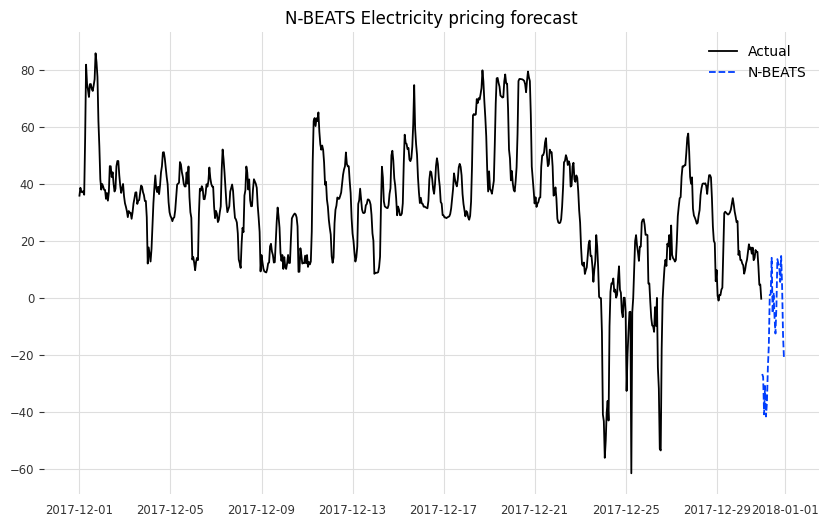

In [ ]:
# Plot the actual values and the N-BEATS
fig, ax = plt.subplots(figsize = (10,6))
ax.plot(df['y']['2017-12':], label = 'Actual')
ax.plot(forecast, label = 'N-BEATS', linestyle = "dashed")
ax.legend()
ax.set_title("N-BEATS Electricity pricing forecast")
plt.show()